# Glacier Retreat and Glacial Lake Formation in the Baba Mountains (2016–2025)

## Project Describtions 

Mountain glaciers are highly sensitive indicators of climate change. As glaciers retreat, meltwater can accumulate in depressions near glacier termini, leading to the formation or expansion of glacial lakes. These lakes can pose significant environmental and natural hazard risks, including the potential for glacial lake outburst floods (GLOFs). Understanding the spatial relationship between glacier retreat and glacial lake formation is therefore important for assessing landscape evolution and potential hazards in high mountain regions.

This project investigates glacier retreat and glacial lake changes in the Baba Mountains of central Afghanistan between 2016 and 2025. Using geospatial datasets derived from sentinel 2 imageries, glacier and glacial lake polygons were mapped for both years using ArcGIS Pro. The analysis is conducted using Python-based geospatial tools within a reproduceable workflow. 

 ## Objectives

The main objectives of this project are:

1. Quantify glacier area change between 2016 and 2025.

2. Identify newly formed or expanded glacial lakes during the same period.

3. Map glacier retreat zones by comparing glacier extents from the two years.

4. Analyze the spatial relationship between glacier retreat and glacial lake formation.


## Data

The analysis uses four geospatial datasets:

1. Glacier polygons for 2016

2. Glacier polygons for 2025

3. Glacial lake polygons for 2016

4. Glacial lake polygons for 2025

These datasets were generated from satellite imagery classification and exported as GeoJSON files. Each dataset includes a Year attribute indicating the observation year.

## Methodology

The analysis workflow includes the following steps:

1. Import glacier and glacial lake datasets using GeoPandas.

2. Reproject datasets into a projected coordinate system suitable for spatial analysis.

3. Calculate glacier area statistics for each year.

4. Identify glacier retreat zones by comparing glacier extents between 2016 and 2025.

5. Detect newly formed or expanded glacial lakes.

5. Evaluate the spatial relationship between glacier retreat and glacial lake development.

## Expected Outcomes

This project aims to provide a clear visualization and quantitative assessment of glacier change in the Baba Mountains. By examining the relationship between glacier retreat and glacial lake formation, the analysis contributes to understanding landscape change and potential future hazards in this high-mountain environment.

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt 

In [3]:
##loading the data

gl2016 = gpd.read_file('../data/raw/glaciers-2016/glaciers_2016.geojson')
gl2025 = gpd.read_file('../data/raw/glaciers-2025/glaciers_2025.geojson')

lk2016 = gpd.read_file('../data/raw/glacial-lakes-2016/glacial_lakes_2016.geojson')
lk2025 = gpd.read_file('../data/raw/glacial-lakes-2025/glacial_lakes_2025.geojson') 

In [7]:
## quick look at the data

print('Glaciers 2016:', len(gl2016))
print('Glaciers 2025:', len(gl2025))
print('Lakes 2016:', len(lk2016))
print('Lakes 2025:', len(lk2025))

Glaciers 2016: 56
Glaciers 2025: 25
Lakes 2016: 35
Lakes 2025: 40


In [8]:
gl2016.head(2)

,OBJECTID,gridcode,ClassName,Longitude,Latitude,GLIMS_ID,ClassValue,Shape_Leng,AreasqKM,Elv_min,...,Slope_min,Slope_mean,Slope_max,Aspect_Code,Aspect_Degree,Aspect_Label,Shape_Length,Shape_Area,Year,geometry
0,1,189,Glacier,67.620,34.655,G067620E34655N,1,1492.778270,0.043829,4534,...,11,34,52,2,45,Northeast,1492.778270,43829.169989,2016,"POLYGON ((67.61985 34.65385, 67.61986 34.65386..."
1,3,57,Glacier,67.639,34.654,G067639E34654N,1,628.227699,0.019746,4361,...,12,36,62,1,0,North,628.227699,19745.955856,2016,"POLYGON ((67.63916 34.65308, 67.63917 34.65307..."


In [9]:
lk2016.head(2)

,OBJECTID,gridcode,ClassName,Longitude,Latitude,GLIMS_ID,ClassValue,Shape_Leng,AreasqKM,Altitude,Shape_Length,Shape_Area,Year,geometry
0,1,2,Glacier_Lake,67.678,34.665,GL067678E34665N,2,640.328853,0.025581,4057,640.328853,25580.533854,2016,"POLYGON ((67.6766 34.66451, 67.67659 34.6645, ..."
1,2,3,Glacier_Lake,67.715,34.661,GL067715E34661N,2,577.641931,0.018082,4145,577.641931,18081.769881,2016,"POLYGON ((67.71461 34.66036, 67.71462 34.66034..."


In [10]:
#checking the coordinate reference system (CRS) of the datasets
print('Glaciers 2016 CRS:', gl2016.crs)
print('Glaciers 2025 CRS:', gl2025.crs)
print('Lakes 2016 CRS:', lk2016.crs)
print('Lakes 2025 CRS:', lk2025.crs)

Glaciers 2016 CRS: EPSG:4326
Glaciers 2025 CRS: EPSG:4326
Lakes 2016 CRS: EPSG:4326
Lakes 2025 CRS: EPSG:4326


The dataset was exported to a WGS 84 cordinate system, to do all the calculations, here I would reproject it to UTM Zone 42N. 

In [11]:
target_crs = "EPSG:32642"

gl2016 = gl2016.to_crs(target_crs)
gl2025 = gl2025.to_crs(target_crs)
lk2016 = lk2016.to_crs(target_crs)
lk2025 = lk2025.to_crs(target_crs)

In [12]:
print('Glaciers 2016 CRS after transformation:', gl2016.crs)
print('Glaciers 2025 CRS after transformation:', gl2025.crs)
print('Lakes 2016 CRS after transformation:', lk2016.crs)
print('Lakes 2025 CRS after transformation:', lk2025.crs)

Glaciers 2016 CRS after transformation: EPSG:32642
Glaciers 2025 CRS after transformation: EPSG:32642
Lakes 2016 CRS after transformation: EPSG:32642
Lakes 2025 CRS after transformation: EPSG:32642


In [16]:
## check for invalid geometries in the datasets
print('Invalid geometries in gl2016:', (~gl2016.is_valid).sum())
print('Invalid geometries in gl2025:', (~gl2025.is_valid).sum())
print('Invalid geometries in lk2016:', (~lk2016.is_valid).sum())
print('Invalid geometries in lk2025:', (~lk2025.is_valid).sum())

Invalid geometries in gl2016: 0
Invalid geometries in gl2025: 0
Invalid geometries in lk2016: 0
Invalid geometries in lk2025: 0


In [15]:
## calculate the area of glaciers and lakes in square kilometers
gl2016['area_km2'] = gl2016['geometry'].area / 1e6
gl2025['area_km2'] = gl2025['geometry'].area / 1e6
lk2016['area_km2'] = lk2016['geometry'].area / 1e6
lk2025['area_km2'] = lk2025['geometry'].area / 1e6

In [19]:
## creating area summary tables for glaciers and lakes for 2016 and 2025
glacier_summary = pd.DataFrame({
    "Year": [2016, 2025],
    "Feature_Count": [len(gl2016), len(gl2025)],
    "Total_Area_km2": [gl2016["area_km2"].sum(), gl2025["area_km2"].sum()]
})

lake_summary = pd.DataFrame({
    "Year": [2016, 2025],
    "Feature_Count": [len(lk2016), len(lk2025)],
    "Total_Area_km2": [lk2016["area_km2"].sum(), lk2025["area_km2"].sum()]
})

glacier_summary     

,Year,Feature_Count,Total_Area_km2
0,2016,56,2.740424
1,2025,25,1.435261


In [20]:
lake_summary

,Year,Feature_Count,Total_Area_km2
0,2016,35,0.569552
1,2025,40,0.622509


## Initial Observations
The summary tables provide an initial comparison of glacier and glacial lake conditions in 2016 and 2025. Because glacier polygon IDs are not directly comparable across years, differences in glacier count should be interpreted cautiously. A lower glacier count in 2025 does not necessarily mean that the missing count represents complete glacier disappearance; it may also reflect glacier fragmentation, merging, or classification differences. For this reason, the primary indicators used in this study are total area change and spatial change patterns.

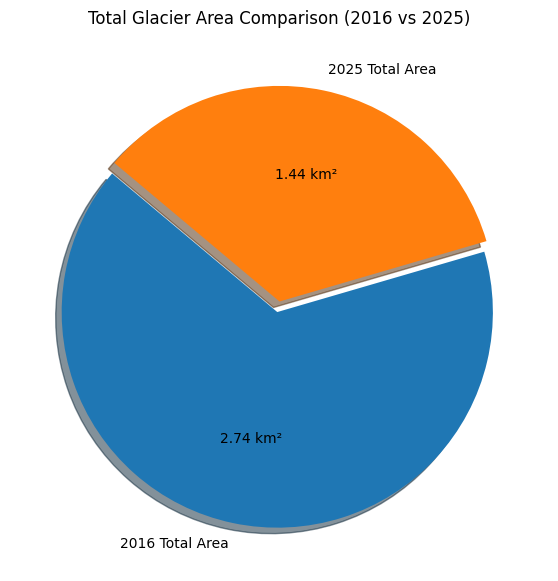

In [23]:
## glacier area plot
import matplotlib.pyplot as plt

areas = glacier_summary["Total_Area_km2"]
labels = ["2016 Total Area", "2025 Total Area"]

def area_label(pct, allvals):
    absolute = pct/100.*sum(allvals)
    return f"{absolute:.2f} km²"

plt.figure(figsize=(7,7))

plt.pie(
    areas,
    labels=labels,
    autopct=lambda pct: area_label(pct, areas),
    startangle=140,
    explode=(0.05,0),
    shadow=True
)

plt.title("Total Glacier Area Comparison (2016 vs 2025)")

plt.show()

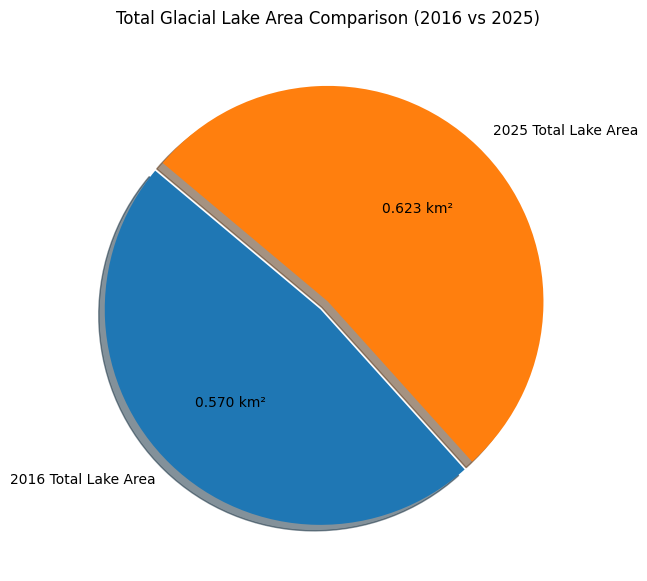

In [24]:
areas = lake_summary["Total_Area_km2"]
labels = ["2016 Total Lake Area", "2025 Total Lake Area"]

def area_label(pct, allvals):
    absolute = pct/100.*sum(allvals)
    return f"{absolute:.3f} km²"

plt.figure(figsize=(7,7))

plt.pie(
    areas,
    labels=labels,
    autopct=lambda pct: area_label(pct, areas),
    startangle=140,
    explode=(0.05,0),
    shadow=True
)

plt.title("Total Glacial Lake Area Comparison (2016 vs 2025)")

plt.show()

## Visualization of Glacier and Glacial Lake Area Changes


The pie charts shows the total mapped glacier area decreased from 2.74 km² in 2016 to 1.44 km² in 2025, indicating significant glacier retreat within the study area over the nine-year period.

In contrast, the glacial lake comparison reveals a slight increase in lake area. The total glacial lake surface area increased from   0.57 km² in 2016 to 0.62 km² in 2025, suggesting that meltwater accumulation may be contributing to lake expansion or the formation of new lakes.

Although glacier counts differ between the two years, the change in feature count does not necessarily indicate that individual glaciers completely disappeared. Differences in count may also reflect glacier fragmentation, merging, or classification differences. For this reason, the primary indicators used in this analysis are total area change and spatial patterns of change.


## Spatial Change Analysis: Glacier Retreat


In [25]:
## creating union of glacier geometries for 2016 and 2025 to visualize overall glacier extent
gl2016_union = gl2016.dissolve()
gl2025_union = gl2025.dissolve()

In [27]:
## calculating glacier retreat by finding the difference between 2016 and 2025 glacier extents
glacier_retreat = gpd.overlay(gl2016_union, gl2025_union, how='difference')

## calculating the area of glacier retreat in square kilometers
glacier_retreat['area_km2'] = glacier_retreat.geometry.area / 1e6

glacier_retreat_area = glacier_retreat['area_km2'].sum()

print('Total Glacier Retreat Area:', round(glacier_retreat_area,3), 'km²')

Total Glacier Retreat Area: 1.516 km²


#### Glacier Retreat Area Calculation

Two different measures can be used to estimate glacier change between 2016 and 2025. The first approach compares the total glacier area for each year. However, this method does not capture spatial shifts in glacier boundaries.
To better represent spatial glacier loss, a geometric difference operation was applied using GeoPandas. This overlay analysis identifies all areas where glacier ice existed in 2016 but no longer exists in 2025.
The resulting retreat polygons represent spatial ice loss during the study period. The calculated retreat area is approximately 1.52 km², which is slightly larger than the simple difference between total glacier areas. This occurs because the spatial overlay captures localized boundary changes, glacier fragmentation, and classification differences between the two datasets.

## New Glacial Lake Formation and Expansion

In [36]:
## creating union of lake geometries for 2016 and 2025
lk2016_union = lk2016.dissolve()
lk2025_union = lk2025.dissolve()

## calculating lake expansion (areas present in 2025 but not in 2016)
lk_expansion = gpd.overlay(lk2025_union, lk2016_union, how='difference')

## calculating the area of lake expansion in square kilometers
lk_expansion['area_km2'] = lk_expansion.geometry.area / 1e6

lake_expansion_area = lk_expansion['area_km2'].sum()

print('Total Lake Expansion Area:', round(lake_expansion_area,3), 'km²')

Total Lake Expansion Area: 0.112 km²



To identify new or expanded glacial lakes, a spatial difference analysis was performed between the 2025 and 2016 glacial lake extents. The 2016 lake extent was subtracted from the 2025 lake extent using a GeoPandas overlay operation.

This analysis isolates areas where lakes were present in 2025 but absent in 2016, representing newly formed lakes or lake shoreline expansion. The resulting polygons indicate approximately 0.112 km² of new or expanded glacial lake area during the 2016–2025 period.

The spatial expansion value is larger than the simple difference between total lake areas because the overlay method captures localized shoreline changes and newly formed lakes, while the net area comparison only reflects the overall balance between expansion and shrinkage.

## Identify New Lakes formations

In [43]:
## identiffying lake that do not intersect with any 2016 lake to find newly formed lakes in 2025
lk2025_with_id = lk2025.copy()
lk2025_with_id["lake2025_id"] = range(1, len(lk2025_with_id) + 1)

intersections = gpd.sjoin(
    lk2025_with_id,
    lk2016[["geometry"]],
    how="left",
    predicate="intersects"
)

new_lakes_only = intersections[intersections["index_right"].isna()].copy()

print("Number of newly formed lakes:", len(new_lakes_only))

Number of newly formed lakes: 6


In [45]:
## Finding the 2016 disappeared lake
lk2016_with_id = lk2016.copy()
lk2016_with_id["lake2016_id"] = range(1, len(lk2016_with_id) + 1)

intersections_lost = gpd.sjoin(
    lk2016_with_id,
    lk2025[["geometry"]],
    how="left",
    predicate="intersects"
)

lost_lakes_only = intersections_lost[intersections_lost["index_right"].isna()].copy()

print("Number of disappeared lakes:", len(lost_lakes_only))
lost_lakes_only[["lake2016_id", "Year", "area_km2", "geometry"]]

Number of disappeared lakes: 1


,lake2016_id,Year,area_km2,geometry
18,19,2016,0.002506,"POLYGON ((375867.308 3835193.99, 375874.456 38..."


## Key take away!!

A simple comparison of glacial lake counts between 2016 and 2025 suggests that the number of lakes increased from 35 to 40, indicating a net increase of five lakes during the study period. However, relying solely on lake counts does not fully capture the dynamics of glacial lake evolution.

Spatial comparison between the two datasets reveals that six new glacial lakes formed between 2016 and 2025, while one lake that existed in 2016 disappeared by 2025. The net increase of five lakes therefore reflects the balance between lake formation and lake disappearance rather than representing only newly formed lakes.

This demonstrates that feature counts alone cannot accurately describe landscape change, because they do not account for processes such as lake disappearance, shoreline expansion, or fragmentation. Spatial overlay analysis provides a more reliable method for identifying where lakes have formed, expanded, or disappeared over time.

By applying spatial overlay techniques, the analysis captures the true dynamics of glacial lake evolution in the Baba Mountains and provides a clearer understanding of how glacial lakes respond to glacier retreat.

## Relationship Between Glacier Retreat and New Glacial Lakes

In [39]:
lake_retreat_overlap = gpd.overlay(lk_expansion, glacier_retreat, how='intersection')

lake_retreat_overlap['area_km2'] = lake_retreat_overlap.geometry.area / 1e6

overlap_area = lake_retreat_overlap['area_km2'].sum()

print('Lake expansion overlapping glacier retreat:', round(overlap_area, 3), 'km²')

Lake expansion overlapping glacier retreat: 0.02 km²


In [38]:
overlap_pct = (overlap_area / lake_expansion_area) * 100
print('Percent of lake expansion overlapping glacier retreat:', round(overlap_pct,1), '%')

Percent of lake expansion overlapping glacier retreat: 17.6 %



To investigate whether glacial lake formation is associated with glacier retreat, the polygons representing lake expansion were intersected with the glacier retreat polygons.

The analysis shows that approximately 0.02 km² of newly formed or expanded glacial lake area directly overlaps areas where glacier ice retreated between 2016 and 2025. This represents roughly 18% of the total lake expansion area identified during the study period.

This spatial overlap indicates that a portion of the new glacial lakes formed directly within zones of recent glacier retreat. However, the majority of lake expansion occurs outside the exact retreat polygons. This is expected because meltwater often accumulates slightly downslope from the glacier margin, forming lakes adjacent to retreating ice rather than directly within former glacier footprints.

These results support the hypothesis that glacier retreat contributes to glacial lake formation and expansion in the Baba Mountains, although the spatial relationship may extend beyond the immediate retreat zones.

## Interactive Visualization of Glacier Retreat and Glacial Lake Evolution

In [ ]:
import ee

ee.Authenticate(auth_mode='notebook')
ee.Initialize(project='geo5830')

In [ ]:
import ee
import geemap
import geopandas as gpd


# Initialize Earth Engine
ee.Initialize(project='geo5830')

#2. Load Sentinel-2 imagery

# 2025 imagery
s2_2025_collection = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterDate('2025-09-18', '2025-09-20')
    .filter(ee.Filter.inList('MGRS_TILE', ['42SUD', '42SVD']))
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
)

n2025 = s2_2025_collection.size().getInfo()
print('2025 images found:', n2025)

s2_2025 = s2_2025_collection.mosaic() if n2025 > 0 else None

# 2016 imagery
s2_2016_collection = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterDate('2016-09-24', '2016-09-25')
    .filter(ee.Filter.inList('MGRS_TILE', ['42SUD', '42SVD']))
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 15))
)

n2016 = s2_2016_collection.size().getInfo()
print('2016 images found:', n2016)

s2_2016 = s2_2016_collection.mosaic() if n2016 > 0 else None

# Load local GeoJSON layers


gl2016_map = gpd.read_file('../data/raw/glaciers-2016/glaciers_2016.geojson').to_crs(epsg=4326)
gl2025_map = gpd.read_file('../data/raw/glaciers-2025/glaciers_2025.geojson').to_crs(epsg=4326)

lk2016_map = gpd.read_file('../data/raw/glacial-lakes-2016/glacial_lakes_2016.geojson').to_crs(epsg=4326)
lk2025_map = gpd.read_file('../data/raw/glacial-lakes-2025/glacial_lakes_2025.geojson').to_crs(epsg=4326)

# 4. Create projected layers for spatial analysis

gl2016_proj = gl2016_map.to_crs(epsg=32642)
gl2025_proj = gl2025_map.to_crs(epsg=32642)

lk2016_proj = lk2016_map.to_crs(epsg=32642)
lk2025_proj = lk2025_map.to_crs(epsg=32642)

# Dissolve glacier and lake extents
gl2016_union = gl2016_proj.dissolve()
gl2025_union = gl2025_proj.dissolve()

lk2016_union = lk2016_proj.dissolve()
lk2025_union = lk2025_proj.dissolve()

# glacier count change
print('Glacier count change from 2016 to 2025:', len(gl2025_proj) - len(gl2016_proj))

# Glacier retreat (2016 - 2025)

glacier_retreat = gpd.overlay(gl2016_union, gl2025_union, how='difference').to_crs(epsg=4326)

# Lake expansion area (2025 - 2016)

lake_expansion = gpd.overlay(lk2025_union, lk2016_union, how='difference').to_crs(epsg=4326)

# Identify new lakes

lk2025_with_id = lk2025_proj.copy()
lk2025_with_id['lake2025_id'] = range(1, len(lk2025_with_id) + 1)

joined_new = gpd.sjoin(
    lk2025_with_id,
    lk2016_proj[['geometry']],
    how='left',
    predicate='intersects'
)

new_lakes_only = joined_new[joined_new['index_right'].isna()].copy().to_crs(epsg=4326)
print('New lakes in 2025:', len(new_lakes_only))

# 8. Identify disappeared lakes

lk2016_with_id = lk2016_proj.copy()
lk2016_with_id['lake2016_id'] = range(1, len(lk2016_with_id) + 1)

joined_lost = gpd.sjoin(
    lk2016_with_id,
    lk2025_proj[['geometry']],
    how='left',
    predicate='intersects'
)

lost_lakes_only = joined_lost[joined_lost['index_right'].isna()].copy().to_crs(epsg=4326)
print('Disappeared lakes from 2016:', len(lost_lakes_only))

# Create interactive map


m = geemap.Map()

xmin, ymin, xmax, ymax = gl2025_map.total_bounds
center_lon = (xmin + xmax) / 2
center_lat = (ymin + ymax) / 2

m.set_center(center_lon, center_lat, 12)

# Sentinel-2 visualization parameters


vis_params = {
    'bands': ['B11', 'B8', 'B4'],
    'min': 0,
    'max': 4000,
    'gamma': 1.1,
}

if s2_2025 is not None:
    m.addLayer(s2_2025, vis_params, 'Sentinel-2 Sept 2025')

if s2_2016 is not None:
    m.addLayer(s2_2016, vis_params, 'Sentinel-2 Sept 2016')

# Add glacier layers

m.add_gdf(
    gl2016_map,
    layer_name='Glaciers 2016',
    style={'color': 'cyan', 'weight': 2, 'fillOpacity': 0.05}
)

m.add_gdf(
    gl2025_map,
    layer_name='Glaciers 2025',
    style={'color': 'blue', 'weight': 2, 'fillOpacity': 0.05}
)

m.add_gdf(
    glacier_retreat,
    layer_name='Glacier Retreat 2016-2025',
    style={'color': 'red', 'weight': 1, 'fillColor': 'red', 'fillOpacity': 0.6}
)

# Add lake layers


m.add_gdf(
    lk2016_map,
    layer_name='Glacial Lakes 2016',
    style={'color': 'navy', 'weight': 2, 'fillOpacity': 0.05}
)

m.add_gdf(
    lk2025_map,
    layer_name='Glacial Lakes 2025',
    style={'color': 'magenta', 'weight': 2, 'fillOpacity': 0.05}
)

m.add_gdf(
    lake_expansion,
    layer_name='Lake Expansion 2016-2025',
    style={'color': 'yellow', 'weight': 1, 'fillColor': 'yellow', 'fillOpacity': 0.7}
)

m.add_gdf(
    new_lakes_only,
    layer_name='New Lakes in 2025',
    style={'color': 'green', 'weight': 2, 'fillColor': 'green', 'fillOpacity': 0.7}
)

m.add_gdf(
    lost_lakes_only,
    layer_name='Disappeared Lakes from 2016',
    style={'color': 'orange', 'weight': 2, 'fillColor': 'orange', 'fillOpacity': 0.8}
)

# Legend and controls

legend_dict = {
    'Glaciers 2016': 'cyan',
    'Glaciers 2025': 'blue',
    'Glacier Retreat 2016-2025': 'red',
    'Glacial Lakes 2016': 'navy',
    'Glacial Lakes 2025': 'magenta',
    'Lake Expansion 2016-2025': 'yellow',
    'New Lakes in 2025': 'green',
    'Disappeared Lakes from 2016': 'orange'
}

m.add_legend(title='Legend', legend_dict=legend_dict)
m.addLayerControl()

m

2025 images found: 2
2016 images found: 2
Glacier count change from 2016 to 2025: -31
New lakes in 2025: 6
Disappeared lakes from 2016: 1


Map(center=[np.float64(34.62953384104014), np.float64(67.8059816068853)], controls=(WidgetControl(options=['po…


An interactive geemap visualization was created to examine glacier retreat and glacial lake evolution in the Baba Mountains between 2016 and 2025. Sentinel-2 satellite imagery was used as a base layer to provide visual context for glacier and lake boundaries.
The map includes glacier extents for both years, glacier retreat areas, glacial lake outlines, newly formed lakes, and lakes that disappeared during the study period. The results show that six new glacial lakes formed between 2016 and 2025, while one lake present in 2016 disappeared by 2025. These spatial patterns illustrate the dynamic relationship between glacier retreat and glacial lake development.
The interactive map allows users to toggle layers and visually explore the spatial relationship between glacier change and lake formation across the study area.